In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from statsmodels.tsa.api import VAR
from retrieve.get_data import get_yield

In [2]:
# ── Data ──────────────────────────────────────────────────────────────────────
term     = 5
duration = 5.0

raw_yields = get_yield(term, freq="W-FRI") / 100
dy         = raw_yields.diff().dropna()

carry     = raw_yields.shift(1).reindex(dy.index) / 52
bond_rets = carry - duration * dy

countries = bond_rets.columns.tolist()
n         = len(countries)
idx       = bond_rets.index

print(f"Assets ({n}): {countries}")
print(f"Date range: {idx.min().date()} to {idx.max().date()} ({len(idx)} weeks)")

Assets (11): ['US', 'UK', 'FRA', 'GER', 'AUS', 'INDO', 'INDIA', 'JAPAN', 'SWITZ', 'BRAZIL', 'MEXICO']
Date range: 2012-02-03 to 2026-03-13 (737 weeks)


In [3]:
# ── Tangency optimizer with optional EM cap ───────────────────────────────────
def tangency_weights(mu, Sigma, em_idx=None, em_cap=1.0):
    """Long-only tangency portfolio with optional combined EM weight cap."""
    k  = len(mu)
    w0 = np.ones(k) / k

    def neg_sharpe(w):
        ret = float(w @ mu)
        vol = np.sqrt(max(float(w @ Sigma @ w), 1e-16))
        return -ret / vol

    constraints = [{"type": "eq", "fun": lambda w: w.sum() - 1}]
    if em_idx is not None and em_cap < 1.0:
        constraints.append({
            "type": "ineq",
            "fun": lambda w: em_cap - w[em_idx].sum()
        })

    res = minimize(neg_sharpe, w0, method="SLSQP",
                   bounds=[(0.0, 1.0)] * k,
                   constraints=constraints,
                   options={"ftol": 1e-12, "maxiter": 500})
    return res.x if res.success else w0

In [4]:
# ── Parameters ────────────────────────────────────────────────────────────────
lookback       = 104    # covariance window for tangency weights
vol_lookback   = 104    # rolling vol window for VAR signal normalisation
p_var          = 1      # VAR lag length (AIC-optimal, from testing.ipynb)
gamma          = 0.75   # tilt strength — OOS-optimal from gamma sensitivity test
em_cap         = 0.50   # max combined weight for EM countries
em_countries   = ['INDIA', 'MEXICO', 'INDO', 'BRAZIL']
starting_portfolio = 100_000.0
split_date_str = "2019-01-01"

In [5]:
# ── Train/test split ──────────────────────────────────────────────────────────
split_date = idx[idx >= split_date_str][0]
split_i    = idx.get_loc(split_date)
start_i    = max(split_i, lookback + 1, vol_lookback + 1)

# EM country indices for constraint
em_idx = np.array([countries.index(c) for c in em_countries if c in countries])
print(f"OOS from: {split_date.date()}  |  EM countries capped at {em_cap:.0%}: {em_countries}")

OOS from: 2019-01-04  |  EM countries capped at 50%: ['INDIA', 'MEXICO', 'INDO', 'BRAZIL']


In [6]:
# ── Walk-forward loop: Tangency + VAR Tilt + EM cap ───────────────────────────
portfolio  = pd.Series(np.nan, index=idx)
weights_df = pd.DataFrame(np.nan, index=idx, columns=countries)

portfolio.iloc[start_i] = starting_portfolio

for i in range(start_i, len(idx) - 1):
    end_date  = idx[i]
    next_date = idx[i + 1]

    window = bond_rets.loc[:end_date].tail(lookback).dropna()
    Sigma  = window.cov().values
    mu     = raw_yields.loc[end_date].values / 52
    w_tang = tangency_weights(mu, Sigma, em_idx=em_idx, em_cap=em_cap)

    train_var = dy.loc[:end_date].replace([np.inf, -np.inf], np.nan).dropna()
    train_var = train_var.loc[:, train_var.nunique() > 1]

    try:
        res   = VAR(train_var).fit(p_var)
        fcast = res.forecast(y=train_var.values[-p_var:], steps=1)[0]
        names = res.names
        roll_vol = dy.loc[:end_date].tail(vol_lookback).std()

        tilt = np.zeros(n)
        for k_i, c in enumerate(countries):
            if c not in names:
                continue
            vol = roll_vol.get(c, np.nan)
            if pd.isna(vol) or vol == 0:
                continue
            tilt[k_i] = np.clip(-fcast[names.index(c)] / vol, -1.0, 1.0)

        w_adj = w_tang * np.maximum(0.0, 1.0 + gamma * tilt)
        w_sum = w_adj.sum()
        w = w_adj / w_sum if w_sum > 1e-12 else w_tang

    except Exception:
        w = w_tang

    weights_df.loc[end_date] = w
    r_next = bond_rets.loc[next_date].values
    portfolio.loc[next_date] = portfolio.loc[end_date] * (1.0 + float(w @ r_next))

portfolio = portfolio.ffill()
print("Done.")

Done.


In [7]:
# ── Benchmarks: pure tangency (with EM cap) + equal-weight ────────────────────
port_tang       = pd.Series(np.nan, index=idx)
weights_tang_df = pd.DataFrame(np.nan, index=idx, columns=countries)
port_tang.iloc[start_i] = starting_portfolio

for i in range(start_i, len(idx) - 1):
    end_date  = idx[i]
    next_date = idx[i + 1]
    window = bond_rets.loc[:end_date].tail(lookback).dropna()
    Sigma  = window.cov().values
    mu     = raw_yields.loc[end_date].values / 52
    w      = tangency_weights(mu, Sigma, em_idx=em_idx, em_cap=em_cap)
    weights_tang_df.loc[end_date] = w
    port_tang.loc[next_date] = port_tang.loc[end_date] * (1.0 + float(w @ bond_rets.loc[next_date].values))
port_tang = port_tang.ffill()

ew_port = pd.Series(np.nan, index=idx)
ew_port.iloc[start_i] = starting_portfolio
for i in range(start_i, len(idx) - 1):
    end_date  = idx[i]
    next_date = idx[i + 1]
    ew_port.loc[next_date] = ew_port.loc[end_date] * (1.0 + float(bond_rets.loc[next_date].mean()))
ew_port = ew_port.ffill()

print("Benchmarks done.")

Benchmarks done.


In [8]:
# ── Performance comparison ────────────────────────────────────────────────────
rf_weekly = raw_yields['US'].reindex(idx) / 52

def perf(port, label):
    p    = port.loc[split_date:].dropna()
    wr   = p.pct_change().dropna()
    rf   = rf_weekly.reindex(wr.index)
    ex   = wr - rf
    sh   = (wr.mean() / wr.std(ddof=0)) * np.sqrt(52)
    exsh = (ex.mean() / ex.std(ddof=0)) * np.sqrt(52)
    tot  = p.iloc[-1] / p.iloc[0] - 1
    dd   = ((p - p.cummax()) / p.cummax()).min()
    hit  = (wr > 0).mean()
    vol  = wr.std(ddof=0) * np.sqrt(52)
    print(f"  {label:28s}  Sharpe={sh:+.2f}  ExSharpe={exsh:+.2f}  "
          f"Tot={tot:+.1%}  Vol={vol:.2%}  MaxDD={dd:.2%}  Hit={hit:.1%}")

print(f"OOS: {split_date.date()} to {idx[-1].date()}\n")
perf(portfolio,  "Tangency + VAR Tilt")
perf(port_tang,  "Pure Tangency")
perf(ew_port,    "Equal-Weight")

OOS: 2019-01-04 to 2026-03-13

  Tangency + VAR Tilt           Sharpe=+1.53  ExSharpe=+0.29  Tot=+26.6%  Vol=2.15%  MaxDD=-4.52%  Hit=63.2%
  Pure Tangency                 Sharpe=+1.50  ExSharpe=+0.27  Tot=+26.3%  Vol=2.17%  MaxDD=-4.73%  Hit=62.7%
  Equal-Weight                  Sharpe=+0.83  ExSharpe=-0.04  Tot=+19.8%  Vol=3.08%  MaxDD=-10.41%  Hit=57.6%


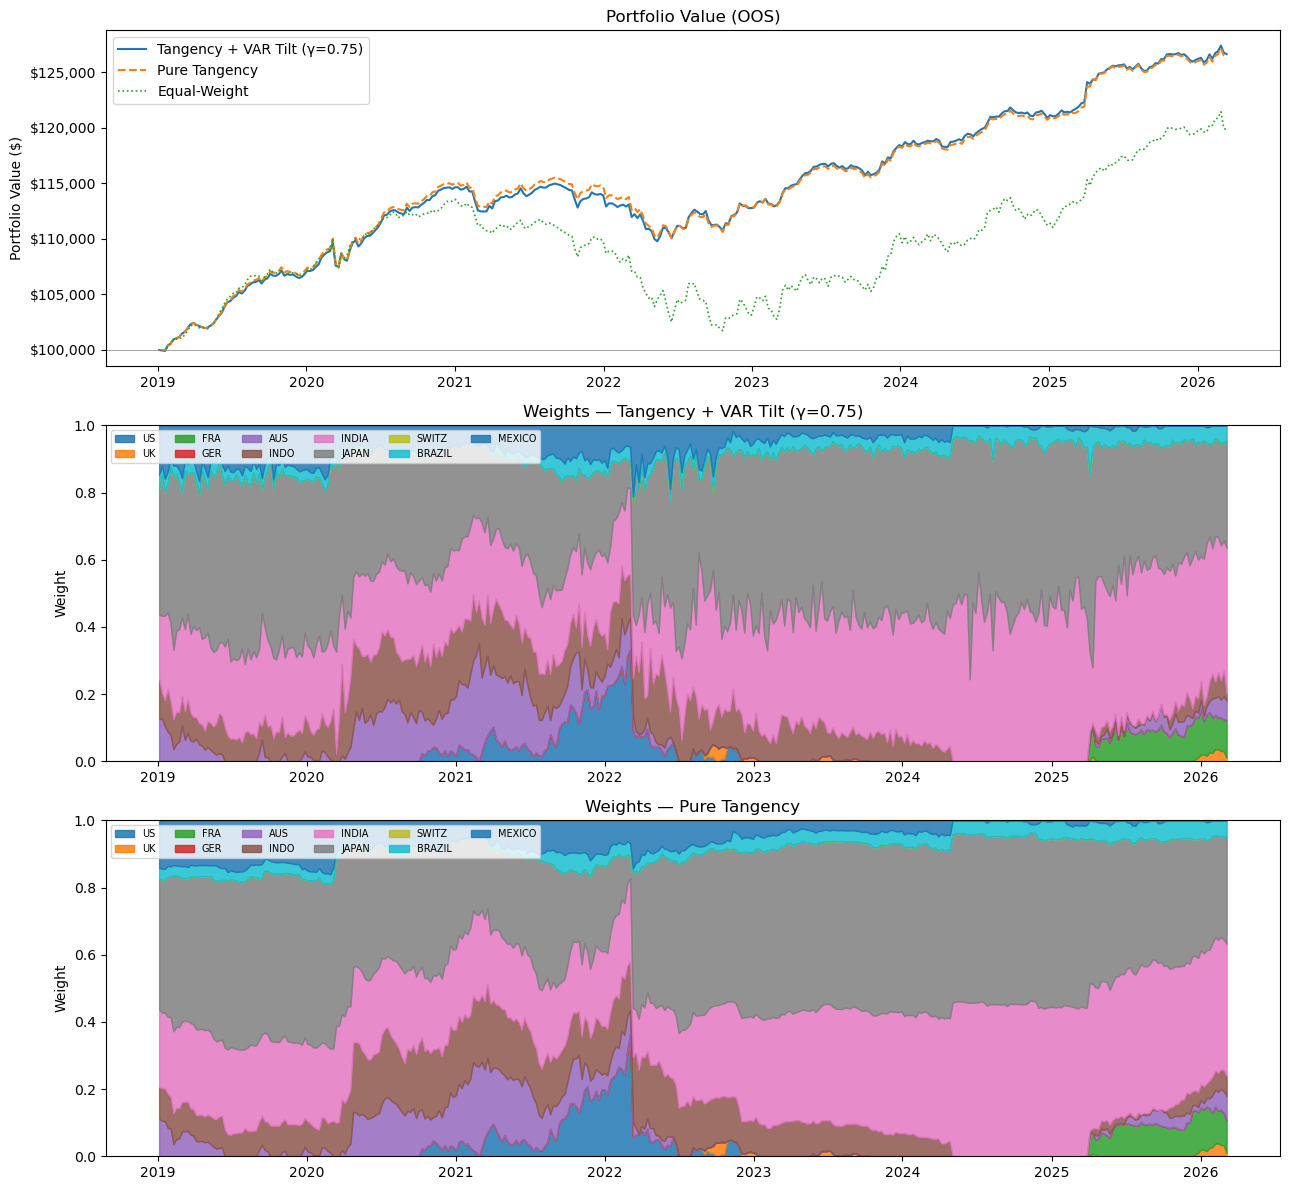

In [9]:
# ── Plots ─────────────────────────────────────────────────────────────────────
port_oos = portfolio.loc[split_date:].dropna()
tang_oos = port_tang.loc[split_date:].dropna()
ew_oos   = ew_port.loc[split_date:].dropna()

w_oos      = weights_df.loc[split_date:].dropna(how='all').astype(float)
w_tang_oos = weights_tang_df.loc[split_date:].dropna(how='all').astype(float)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
country_colors = {c: colors[i % len(colors)] for i, c in enumerate(countries)}

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

# ── Portfolio value ───────────────────────────────────────────────────────────
axes[0].plot(port_oos.index, port_oos.values, lw=1.5, label=f"Tangency + VAR Tilt (γ={gamma})")
axes[0].plot(tang_oos.index, tang_oos.values, lw=1.5, ls='--', label="Pure Tangency")
axes[0].plot(ew_oos.index,   ew_oos.values,   lw=1.2, ls=':', label="Equal-Weight")
axes[0].axhline(starting_portfolio, color='grey', lw=0.5)
axes[0].set_title("Portfolio Value (OOS)")
axes[0].set_ylabel("Portfolio Value ($)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

# ── Tangency + VAR Tilt weights ───────────────────────────────────────────────
bottom = np.zeros(len(w_oos))
for col in countries:
    axes[1].fill_between(w_oos.index, bottom, bottom + w_oos[col].values,
                         label=col, color=country_colors[col], alpha=0.85)
    bottom += w_oos[col].fillna(0).values
axes[1].set_ylim(0, 1)
axes[1].set_title(f"Weights — Tangency + VAR Tilt (γ={gamma})")
axes[1].set_ylabel("Weight")
axes[1].legend(ncol=6, fontsize=7, loc='upper left')

# ── Pure tangency weights ─────────────────────────────────────────────────────
bottom = np.zeros(len(w_tang_oos))
for col in countries:
    axes[2].fill_between(w_tang_oos.index, bottom, bottom + w_tang_oos[col].values,
                         label=col, color=country_colors[col], alpha=0.85)
    bottom += w_tang_oos[col].fillna(0).values
axes[2].set_ylim(0, 1)
axes[2].set_title("Weights — Pure Tangency")
axes[2].set_ylabel("Weight")
axes[2].legend(ncol=6, fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

gamma=0.00  Sharpe=+2.21  ExSharpe=+1.43  Tot=+71.8%  MaxDD=-5.55%
gamma=0.25  Sharpe=+2.23  ExSharpe=+1.45  Tot=+72.3%  MaxDD=-5.46%
gamma=0.50  Sharpe=+2.25  ExSharpe=+1.46  Tot=+72.8%  MaxDD=-5.39%
gamma=0.75  Sharpe=+2.26  ExSharpe=+1.47  Tot=+73.3%  MaxDD=-5.32%
gamma=1.00  Sharpe=+2.25  ExSharpe=+1.47  Tot=+73.4%  MaxDD=-5.27%
gamma=1.50  Sharpe=+2.24  ExSharpe=+1.46  Tot=+73.4%  MaxDD=-5.41%
gamma=2.00  Sharpe=+2.22  ExSharpe=+1.44  Tot=+72.7%  MaxDD=-5.78%


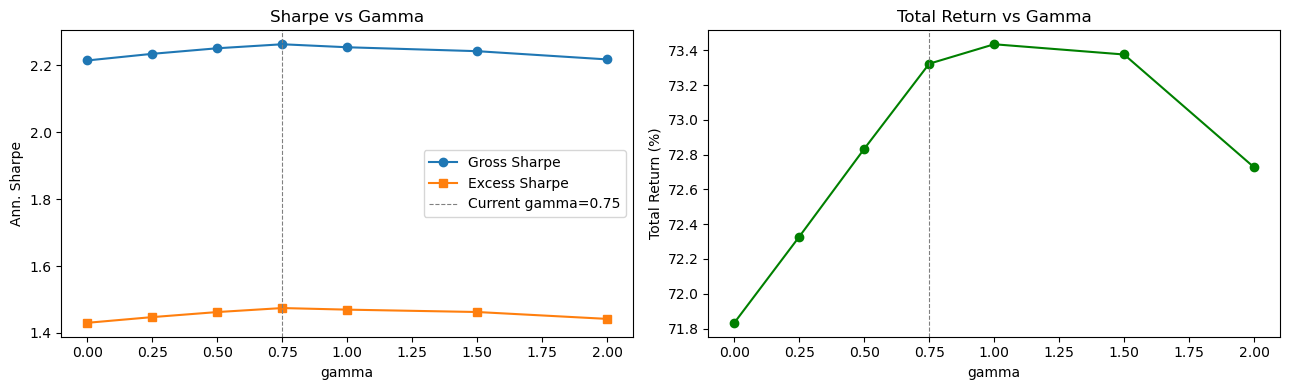

In [10]:
# ── Gamma sensitivity ─────────────────────────────────────────────────────────
gammas      = [0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]
gamma_results = []

for g in gammas:
    port_g = pd.Series(np.nan, index=idx)
    port_g.iloc[start_i] = starting_portfolio

    for i in range(start_i, len(idx) - 1):
        end_date  = idx[i]
        next_date = idx[i + 1]

        window = bond_rets.loc[:end_date].tail(lookback).dropna()
        Sigma  = window.cov().values
        mu     = raw_yields.loc[end_date].values / 52
        w_tang = tangency_weights(mu, Sigma)

        train_var = dy.loc[:end_date].replace([np.inf, -np.inf], np.nan).dropna()
        train_var = train_var.loc[:, train_var.nunique() > 1]

        try:
            res   = VAR(train_var).fit(p_var)
            fcast = res.forecast(y=train_var.values[-p_var:], steps=1)[0]
            names = res.names
            roll_vol = dy.loc[:end_date].tail(vol_lookback).std()

            tilt = np.zeros(n)
            for k_i, c in enumerate(countries):
                if c not in names:
                    continue
                vol = roll_vol.get(c, np.nan)
                if pd.isna(vol) or vol == 0:
                    continue
                tilt[k_i] = np.clip(-fcast[names.index(c)] / vol, -1.0, 1.0)

            w_adj = w_tang * np.maximum(0.0, 1.0 + g * tilt)
            w_sum = w_adj.sum()
            w = w_adj / w_sum if w_sum > 1e-12 else w_tang
        except Exception:
            w = w_tang

        r_next = bond_rets.loc[next_date].values
        port_g.loc[next_date] = port_g.loc[end_date] * (1.0 + float(w @ r_next))

    port_g = port_g.ffill()
    oos = port_g.loc[split_date:].dropna()
    wr  = oos.pct_change().dropna()
    rf  = rf_weekly.reindex(wr.index)
    sh  = (wr.mean() / wr.std(ddof=0)) * np.sqrt(52)
    exsh = ((wr - rf).mean() / (wr - rf).std(ddof=0)) * np.sqrt(52)
    tot  = oos.iloc[-1] / oos.iloc[0] - 1
    dd   = ((oos - oos.cummax()) / oos.cummax()).min()
    gamma_results.append({"gamma": g, "sharpe": sh, "ex_sharpe": exsh,
                          "total": tot, "max_dd": dd, "port": port_g})
    print(f"gamma={g:.2f}  Sharpe={sh:+.2f}  ExSharpe={exsh:+.2f}  Tot={tot:+.1%}  MaxDD={dd:.2%}")

# ── Plot Sharpe vs gamma ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

gs     = [r["gamma"]    for r in gamma_results]
sharps = [r["sharpe"]   for r in gamma_results]
exshs  = [r["ex_sharpe"] for r in gamma_results]
tots   = [r["total"]    for r in gamma_results]

axes[0].plot(gs, sharps, marker='o', label="Gross Sharpe")
axes[0].plot(gs, exshs,  marker='s', label="Excess Sharpe")
axes[0].axvline(gamma, color='grey', ls='--', lw=0.8, label=f"Current gamma={gamma}")
axes[0].set_xlabel("gamma")
axes[0].set_ylabel("Ann. Sharpe")
axes[0].set_title("Sharpe vs Gamma")
axes[0].legend()

axes[1].plot(gs, [t * 100 for t in tots], marker='o', color='green')
axes[1].axvline(gamma, color='grey', ls='--', lw=0.8)
axes[1].set_xlabel("gamma")
axes[1].set_ylabel("Total Return (%)")
axes[1].set_title("Total Return vs Gamma")

plt.tight_layout()
plt.show()